Procés finalitzat. Mostres totals: 1068
Resultats Regressió Lineal -> R2: 0.8966 | MSE: 0.0021
Coeficient Import_Euros: -0.11204644
Coeficient Any_Mitja_Ponderat: -0.06926555
Coeficient Total_Edificis_Zona: 0.00151703


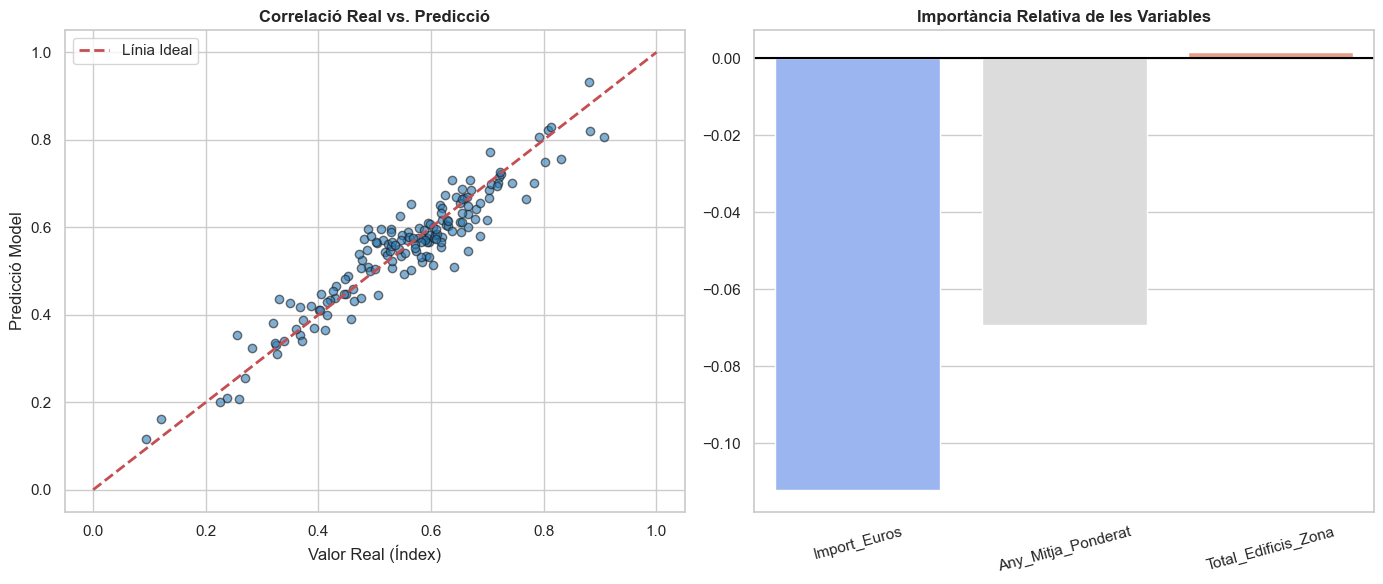

In [1]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- CÀRREGA DE DADES ---
# Es defineix la ruta relativa cap al dataset processat i es llegeix el CSV
ruta_entrada = '../data/processed/dataset_final_IA.csv'
df = pd.read_csv(ruta_entrada)

# --- GENERACIÓ DE LA VARIABLE OBJECTIU (SIMULACIÓ TEMPORAL) ---
# Normalitzem les variables d'entrada per crear una 'y' coherent (0 a 1)
sc_sim = MinMaxScaler()
df[['Euros_n', 'Any_n']] = sc_sim.fit_transform(df[['Import_Euros', 'Any_Mitja_Ponderat']])

# Creació de l'Índex de Vulnerabilitat Real amb un component de soroll estadístic
df['IDV_Real'] = 1 - (df['Euros_n'] * 0.6) - (df['Any_n'] * 0.4) + np.random.normal(0, 0.05, len(df))
df['IDV_Real'] = df['IDV_Real'].clip(0, 1) # Limitem el rang entre 0 i 1

# Eliminem les columnes auxiliars de la normalització de simulació
df = df.drop(columns=['Euros_n', 'Any_n'])

# --- DEFINICIÓ DEL MODEL I ENTRENAMENT ---
# Seleccionem les variables independents (features) i la dependent (target)
features = ['Import_Euros', 'Any_Mitja_Ponderat', 'Total_Edificis_Zona']
X = df[features]
y = df['IDV_Real']

# Divisió del dataset: 85% per entrenament i 15% per a validació final
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

# Estandardització de les dades per assegurar que totes les escales siguin comparables
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_val_s = sc.transform(X_val)

# Inicialització i ajust del model de Regressió Lineal
model = LinearRegression()
model.fit(X_train_s, y_train)

# Generació de prediccions sobre el conjunt de validació
y_pred = model.predict(X_val_s)

# --- EXPORTACIÓ DE RESULTATS A EXCEL ---
# Creem un fitxer detallat per analitzar l'error de cada fila a la carpeta 'processed'
ruta_xlsx = '../data/processed/01_resultats_validacio_detallada.xlsx'
df_validacio = X_val.copy()
df_validacio['Vulnerabilitat_REAL'] = y_val
df_validacio['Vulnerabilitat_PREDITA'] = y_pred
df_validacio['Error_Absolut'] = abs(y_val - y_pred) # Diferència entre real i predit
df_validacio.to_excel(ruta_xlsx, index=True)

# --- REGISTRE HISTÒRIC (LOG) ---
# Càlcul de mètriques globals d'error i precisió
val_r2 = r2_score(y_val, y_pred)
val_mse = mean_squared_error(y_val, y_pred)

# Creació d'un diccionari per guardar la traçabilitat de l'experiment
dades_log = {
    'Data_Hora': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'R2': round(val_r2, 4),
    'MSE': round(val_mse, 4)
}

# Incorporació dels coeficients (pesos) de cada variable de forma dinàmica
for n, p in zip(features, model.coef_):
    dades_log[f'Pes_{n}'] = round(p, 8)

# Convertim a DataFrame i guardem en el CSV històric (mode 'append')
df_log = pd.DataFrame([dades_log])
ruta_csv_log = '../data/01_log_metriques_TFG.csv'
df_log.to_csv(ruta_csv_log, mode='a', index=False, header=not os.path.exists(ruta_csv_log))

# --- SORTIDA DE CONTROL PER CONSOLA ---
# Resum ràpid de l'execució i els pesos assignats pel model
print(f"Procés finalitzat. Mostres totals: {len(df)}")
print(f"Resultats Regressió Lineal -> R2: {val_r2:.4f} | MSE: {val_mse:.4f}")
for n, p in zip(features, model.coef_):
    print(f"Coeficient {n}: {p:.8f}")

# --- VISUALITZACIÓ GRÀFICA ---
# Configuració d'estil i creació de subplots per a la comparativa i els pesos
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gràfic de dispersió: Realitat vs. Predicció del model
ax[0].scatter(y_val, y_pred, alpha=0.6, color='#2c7bb6', edgecolor='k')
ax[0].plot([0, 1], [0, 1], 'r--', lw=2, label='Línia Ideal')
ax[0].set_title('Correlació Real vs. Predicció', fontweight='bold')
ax[0].set_xlabel('Valor Real (Índex)'); ax[0].set_ylabel('Predicció Model')
ax[0].legend()

# Gràfic de barres: Visualització de l'impacte de cada factor d'entrada
sns.barplot(x=features, y=model.coef_, ax=ax[1], hue=features, palette='coolwarm', legend=False)
ax[1].axhline(0, color='black', linewidth=1.5) # Referència al punt zero
ax[1].set_title('Importància Relativa de les Variables', fontweight='bold')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()